# Econ 8208 Assignment 7

- Author: Yuxuan Zhao
- Date: 2026-04-18

In [12]:
using LinearAlgebra, Random
# Using defined functions in ECON8208Tools.jl
include("../ECON8208Tools.jl")
import .ECON8208Tools as tools

# HW 7

Compute equilibria of the following growth model with accounting wedges:

$$
\begin{aligned}
\max_{\{c_t,x_t,\ell_t\}} \quad
& E_0 \sum_{t=0}^{\infty} \beta^t
\left\{
\frac{(c_t \ell_t^{\psi})^{1-\sigma}}{1-\sigma}
\right\} N_t \\
\text{s.t.} \quad
& c_t + (1+\tau_t^x) x_t = r_t k_t + (1-\tau_t^h) w_t h_t + \kappa_t, \\
& N_{t+1} k_{t+1} = \bigl[(1-\delta)k_t + x_t\bigr]N_t, \\
& h_t + \ell_t = 1, \\
& S_t = P_0 + P S_{t-1} + Q \epsilon_t, \\
& S_t = [\log z_t,\tau_t^h,\tau_t^x,\log g_t]', \\
& N_t = (1+\gamma_n)^t, \\
& c_t, x_t \ge 0 \quad \text{in all states.}
\end{aligned}
$$

The production technology is
$$
Y_t = K_t^\theta \bigl(Z_t H_t\bigr)^{1-\theta},
\qquad
Z_t = (1+\gamma_z)^t z_t,
$$
and factor prices satisfy
$$
r_t = \theta K_t^{\theta-1}(Z_t H_t)^{1-\theta},
\qquad
w_t = (1-\theta)K_t^\theta Z_t^{1-\theta} H_t^{-\theta}.
$$

In equilibrium, we impose the resource constraint:
$$
\begin{aligned}
C_t + X_t + G_t &= Y_t, \\
\end{aligned}
$$

The four accounting wedges are the efficiency wedge $z_t$, the labor wedge $\tau_t^h$, the investment wedge $\tau_t^x$, and the government spending wedge $g_t$.

The tasks are:

1. Use U.S. data to infer the wedges.
2. Input all wedges and show that the model and data match exactly.
3. Input wedges one at a time and interpret the results.


This model also has a balanced growth path because productivity grows at the labor-augmenting rate $\gamma_z$. Hence, before solving the equilibrium we detrend the variables that grow over time.

Define the detrended variables as

$$
\tilde c_t=\frac{c_t}{(1+\gamma_z)^t},\qquad
\tilde x_t=\frac{x_t}{(1+\gamma_z)^t},\qquad
\tilde k_t=\frac{k_t}{(1+\gamma_z)^t},
$$

$$
\tilde \kappa_t=\frac{\kappa_t}{(1+\gamma_z)^t},\qquad
\tilde g_t=\frac{g_t}{(1+\gamma_z)^t},\qquad
\tilde G_t=\frac{G_t}{N_t(1+\gamma_z)^t},\qquad
\tilde h_t=h_t,\qquad \tilde \ell_t=\ell_t,
$$

$$
\tilde Y_t=\frac{Y_t}{N_t(1+\gamma_z)^t},\qquad
\tilde K_t=\frac{K_t}{N_t(1+\gamma_z)^t},\qquad
\tilde H_t=\frac{H_t}{N_t},\qquad
\tilde r_t=r_t,\qquad
\tilde w_t=\frac{w_t}{(1+\gamma_z)^t},
$$

$$
\tilde X_t=\frac{X_t}{N_t(1+\gamma_z)^t},\qquad
\tilde C_t=\frac{C_t}{N_t(1+\gamma_z)^t}.
$$

Then period utility becomes

$$
N_t\frac{(c_t\ell_t^{\psi})^{1-\sigma}}{1-\sigma}
=(1+\gamma_n)^t(1+\gamma_z)^{t(1-\sigma)}
\frac{(\tilde c_t\tilde\ell_t^{\psi})^{1-\sigma}}{1-\sigma}.
$$

Therefore, after detrending, the effective discount factor is

$$
\tilde\beta=\beta(1+\gamma_n)(1+\gamma_z)^{1-\sigma}.
$$


The detrended capital accumulation equation is

$$
\tilde k_{t+1}
=\frac{(1-\delta)\tilde k_t+\tilde x_t}{(1+\gamma_n)(1+\gamma_z)}.
$$

Therefore, the detrended household problem can be written as

$$
\begin{aligned}
\max_{\{\tilde c_t,\tilde x_t,\tilde\ell_t\}}\quad
& E_0\sum_{t=0}^{\infty}\tilde\beta^t
\left\{\frac{(\tilde c_t\tilde\ell_t^{\psi})^{1-\sigma}}{1-\sigma}\right\} \\
\text{s.t.}\quad
& \tilde c_t+(1+\tau_{x,t})\tilde x_t
=\tilde r_t\tilde k_t+(1-\tau_{h,t})\tilde w_t\tilde h_t+\tilde\kappa_t, \\
& \tilde k_{t+1}=\frac{(1-\delta)\tilde k_t+\tilde x_t}{(1+\gamma_n)(1+\gamma_z)}, \\
& \tilde h_t+\tilde\ell_t=1, \\
& S_t=P_0 + P S_{t-1}+Q\epsilon_t, \\
& S_t=[\log z_t,\tau_{h,t},\tau_{x,t},\log\tilde g_t]', \\
& \tilde c_t,\tilde x_t\ge 0 \quad \text{in all states.}
\end{aligned}
$$

We have

$$
\tilde Y_t=\frac{Y_t}{N_t(1+\gamma_z)^t},\qquad
\tilde K_t=\frac{K_t}{N_t(1+\gamma_z)^t},\qquad
\tilde H_t=\frac{H_t}{N_t}.
$$

The detrended production function and factor prices are

$$
\tilde Y_t=\tilde K_t^{\theta}(z_t\tilde H_t)^{1-\theta},
\qquad
\tilde r_t=\theta\tilde K_t^{\theta-1}(z_t\tilde H_t)^{1-\theta},
\qquad
\tilde w_t=(1-\theta)\tilde K_t^{\theta}z_t^{1-\theta}\tilde H_t^{-\theta}.
$$

Hence, the detrended market clearing conditions can be written as

$$
\tilde K_t=\tilde k_t,\qquad
\tilde G_t=\tilde g_t,\qquad
\tilde C_t=\tilde c_t,\qquad
\tilde X_t=\tilde x_t,\qquad
\tilde H_t=\tilde h_t,
$$

$$
\tilde K_{t+1}=\frac{(1-\delta)\tilde K_t+\tilde X_t}{(1+\gamma_n)(1+\gamma_z)},
\qquad
\tilde C_t+\tilde X_t+\tilde G_t=\tilde Y_t.
$$


# 4. Data Objects We Need

We have already cleaned U.S. national accounts data for HW6 in

`HW6/data/raw_data.xlsx`.

For the BCA wedge calculation, we only need data analogues for output, consumption, investment, and labor:

$$
\{\tilde y_t,\tilde c_t,\tilde x_t,\tilde h_t\}.
$$

# 5. Calibration Choices

We use the structural parameters calibrated in `HW6.ipynb`.

$$
\beta = 0.97,
\qquad
\psi = 1.55,
\qquad
\sigma = 2.00,
$$

$$
\gamma_n = 0.01,
\qquad
\gamma_z = 0.02,
$$

$$
\theta = 0.368,
\qquad
\delta = 0.072.
$$

This choice means that the data input and the structural calibration both follow HW6. We can still use the CKM MATLAB files as references for the BCA algorithm, but we should not blindly reuse CKM's equilibrium matrices. Any steady state, log-linear decision rule, or observation matrix used to infer the investment wedge should be recomputed under these HW6-calibrated structural parameters.

For the wedge steady state, we will use data-implied values. A practical choice is:

$$
z^{ss}=1,
$$

or equivalently, center $\log z_t$ around its sample mean.

For the other wedges, use sample averages after the wedge series are constructed:

$$
\tau_h^{ss}
=
\frac{1}{T}\sum_{t=1}^T \tau_{h,t},
$$

$$
g^{ss}
=
\frac{1}{T}\sum_{t=1}^T \tilde g_t,
$$

$$
\tau_x^{ss}
=
\frac{1}{T}\sum_{t=1}^T \tau_{x,t}.
$$

This mirrors the BCA logic: structural parameters are calibrated from HW6, while wedges are accounting residuals inferred from U.S. data.


## (a) Use Data for the United States to Infer the Wedges

Using the HW6 cleaned data, three objects are directly pinned down by data and static equilibrium conditions. In this section all variables are detrended model analogues, so we use tildes in the formulas.

### Government/resource wedge

We define the government spending wedge as the residual in the aggregate resource constraint:

$$
\tilde g_t = \tilde y_t - \tilde c_t - \tilde x_t.
$$

This is broader than government purchases alone. It absorbs government spending, net exports, and any other resource-accounting components not explicitly modeled. This mirrors CKM's construction, where net exports are included in the government wedge.


### Efficiency wedge

From production,

$$\tilde y_t = \tilde k_t^{\theta}(z_t \tilde h_t)^{1-\theta},$$

We have:

$$
z_t = \left(\frac{\tilde y_t}{\tilde k_t^{\theta}\tilde h_t^{1-\theta}}\right)^{\frac{1}{1-\theta}}
\quad \Rightarrow \quad
\log z_t = \frac{\log \tilde y_t - \theta\log \tilde k_t - (1-\theta)\log \tilde h_t}{1-\theta}.
$$

### Labor wedge

The household labor FOC is

$$\frac{\psi \tilde c_t}{1-\tilde h_t} = (1-\tau_{h,t})\tilde w_t,$$

and the competitive wage is

$$\tilde w_t = (1-\theta)\frac{\tilde y_t}{\tilde h_t}.$$

Therefore,

$$1-\tau_{h,t}=\frac{\psi \tilde c_t}{1-\tilde h_t}\bigg/\left((1-\theta)\frac{\tilde y_t}{\tilde h_t}\right),$$

or

$$\tau_{h,t}=1-\frac{\psi}{1-\theta}\frac{\tilde c_t}{\tilde y_t}\frac{\tilde h_t}{1-\tilde h_t}.$$


### Inferring the Investment Wedge


The investment wedge cannot be inferred from a purely static equation, because it appears in the intertemporal Euler equation:

$$
(1+\tau_{x,t})U_{c,t}
=
\hat\beta E_t
\left[
U_{c,t+1}
\left(
\theta\frac{\tilde y_{t+1}}{\tilde k_{t+1}}
+
(1-\delta)(1+\tau_{x,t+1})
\right)
\right].
$$

This equation depends on expectations about future marginal utility, future capital returns, and future investment wedges. Therefore, the current investment wedge $\tau_{x,t}$ cannot be backed out from current-period data alone.

Assuming $\tau_{x,t}$ is latent state, $\tilde y_t, \tilde x_t, \tilde h_t, \tilde g_t$ are observed variables, we can use Kalman filter to infer the hidden state $\tau_{x,t}$ from the observed data.



The observed data vector is

$$
Y_t
=
\begin{bmatrix}
\log \tilde y_t \\
\log \tilde x_t \\
\log \tilde h_t \\
\log \tilde g_t
\end{bmatrix}.
$$


The hidden state vector is

$$
X_t
=
\begin{bmatrix}
\log \tilde k_t \\
\log z_t \\
\tau_{h,t} \\
\tau_{x,t} \\
\log \tilde g_t \\
1
\end{bmatrix}.
$$

The first element is the endogenous capital state $\log \tilde k_t$. The final element $1$ is a constant used to handle intercepts.

The wedge vector is

$$
S_t
=
\begin{bmatrix}
\log z_t \\
\tau_{h,t} \\
\tau_{x,t} \\
\log \tilde g_t
\end{bmatrix}.
$$

We assume that the wedge vector follows a first-order vector autoregression:

$$
S_{t+1}
=
P_0 + P S_t + Q\epsilon_{t+1},
$$


At this stage, $S_t$ is not fully observed because $\tau_{x,t}$ is not observed. 

For any candidate values of $P_0$, $P$, and $Q$, solving the log-linearized model gives the capital policy rule

$$
\log \tilde k_{t+1}
=
\gamma_0
+
\gamma_k\log \tilde k_t
+
\gamma_z\log z_t
+
\gamma_h\tau_{h,t}
+
\gamma_x\tau_{x,t}
+
\gamma_g\log \tilde g_t.
$$

Equivalently,

$$
\log \tilde k_{t+1}
=
\begin{bmatrix}
\gamma_k & \gamma_z & \gamma_h & \gamma_x & \gamma_g & \gamma_0
\end{bmatrix}
X_t.
$$

Combining the capital policy rule with the wedge process gives the state transition equation

$$
X_{t+1}
=
A X_t + B\epsilon_{t+1}.
$$

The matrix $A$ is

$$
A
=
\begin{bmatrix}
\gamma_k & \gamma_S' & \gamma_0 \\
0_{4\times 1} & P & P_0 \\
0 & 0_{1\times 4} & 1
\end{bmatrix},
$$

where

$$
\gamma_S'
=
\begin{bmatrix}
\gamma_z & \gamma_h & \gamma_x & \gamma_g
\end{bmatrix}.
$$

The matrix $B$ is

$$
B
=
\begin{bmatrix}
0_{1\times 4}\\
Q\\
0_{1\times 4}
\end{bmatrix}.
$$


Given the state transition equation, solving linearized model, we can use the equilibrium conditions to derive the observation equation:

$$
Y_t = C X_t + \omega_t.
$$

That is,

$$
\begin{bmatrix}
\log \tilde y_t \\
\log \tilde x_t \\
\log \tilde h_t \\
\log \tilde g_t
\end{bmatrix}
=
C
\begin{bmatrix}
\log \tilde k_t \\
\log z_t \\
\tau_{h,t} \\
\tau_{x,t} \\
\log \tilde g_t \\
1
\end{bmatrix}
+
\omega_t.
$$

The observation matrix $C$ comes from the model's log-linear equilibrium conditions: the production function, the labor first-order condition, the resource constraint, the capital accumulation equation, and the Euler equation.


Given a candidate state-space system,

$$
X_{t+1}=AX_t+B\epsilon_{t+1},
$$

$$
Y_t=CX_t+\omega_t,
$$

the Kalman filter can evaluate the likelihood of the observed data sequence $\{Y_t\}_{t=1}^T$ without directly observing the hidden state sequence $\{X_t\}_{t=1}^T$.

Let $\hat X_{t|t}$ denote the estimate of the hidden state after observing data through date $t$, and let $\Sigma_{t|t}$ denote the corresponding state estimation error covariance.

The prediction step is

$$
\hat X_{t+1|t}
=
A\hat X_{t|t},
$$

$$
\Sigma_{t+1|t}
=
A\Sigma_{t|t}A'
+
BB'.
$$

After observing $Y_{t+1}$, the prediction error is

$$
\nu_{t+1}
=
Y_{t+1}
-
C\hat X_{t+1|t}.
$$

The prediction error covariance is

$$
\Omega_{t+1}
=
C\Sigma_{t+1|t}C'
+
R,
$$

where $R$ is the covariance matrix of measurement error $\omega_t$.

The Kalman gain is

$$
K_{t+1}
=
\Sigma_{t+1|t}C'\Omega_{t+1}^{-1}.
$$

The update step is

$$
\hat X_{t+1|t+1}
=
\hat X_{t+1|t}
+
K_{t+1}\nu_{t+1},
$$

$$
\Sigma_{t+1|t+1}
=
\Sigma_{t+1|t}
-
K_{t+1}C\Sigma_{t+1|t}.
$$

The likelihood contribution from date $t+1$ is

$$
-\frac{1}{2}
\left[
\log |\Omega_{t+1}|
+
\nu_{t+1}'\Omega_{t+1}^{-1}\nu_{t+1}
+
n\log(2\pi)
\right],
$$

where $n$ is the dimension of $Y_t$. Summing these terms over time gives the log likelihood.

The maximum likelihood step chooses the parameters governing the wedge process, such as $\bar S$, $P_0$, $P$, and $Q$, to maximize the likelihood of the observed data. For each candidate parameter vector, we:

1. Compute the steady state.
2. Solve the log-linearized model.
3. Construct the state transition matrices $A$ and $B$.
4. Construct the observation matrix $C$.
5. Use the Kalman filter to compute the likelihood of the observed data.
6. Search over parameters until the likelihood is maximized.

After this MLE step, we have the final observation matrix $C$. Only then do we recover the investment wedge path.

The second row of the observation equation is the investment equation:

$$
\log \tilde x_t
=
C_{2,1}\log \tilde k_t
+
C_{2,2}\log z_t
+
C_{2,3}\tau_{h,t}
+
C_{2,4}\tau_{x,t}
+
C_{2,5}\log \tilde g_t
+
C_{2,6}.
$$

At this point, all terms except $\tau_{x,t}$ are known. Therefore, we recover the investment wedge as

$$
\tau_{x,t}
=
\frac{
\log \tilde x_t
-
C_{2,1}\log \tilde k_t
-
C_{2,2}\log z_t
-
C_{2,3}\tau_{h,t}
-
C_{2,5}\log \tilde g_t
-
C_{2,6}
}{
C_{2,4}
}.
$$

This is the logic used in `References/bca/mleannual/wedges.m`:

```text
tauxt = (lxt - C(2,1)*lkt - C(2,2)*lzt - C(2,3)*tault - C(2,5)*lgt - C(2,6)) / C(2,4)
```

## Julia Implementation Step 1: Build the Data Used in HW7

The first object we need is the data vector used by the BCA accounting exercise:

$$
\{Y_t, C_t, X_t, K_t, H_t\}_{t=1}^T .
$$

We reuse the cleaned HW6 national accounts data. All real aggregate variables are converted into real per-capita model units.

Output is real GDP per capita:

$$
Y_t = \frac{\text{real GDP}_t}{N_t}.
$$

Consumption and investment are constructed in the same real units as output. We first compute their nominal shares and then multiply by real GDP:

$$
C_t
=
\frac{\text{PCE}_t}{\text{nominal GDP}_t}
\cdot
\frac{\text{real GDP}_t}{N_t},
$$

$$
X_t
=
\frac{\text{gross investment}_t}{\text{nominal GDP}_t}
\cdot
\frac{\text{real GDP}_t}{N_t}.
$$

Capital is constructed analogously from the private fixed asset stock:

$$
K_t
=
\frac{\text{private fixed assets}_t}{\text{nominal GDP}_t}
\cdot
\frac{\text{real GDP}_t}{N_t}.
$$

Labor is the HW6 hours measure:

$$
H_t = h_t.
$$

At this step we do **not** separately load government spending. Following the BCA resource-constraint logic, the government/resource wedge will be constructed later as

$$
G_t = Y_t - C_t - X_t.
$$

So the output of Step 1 is the minimal data file

$$
\{Y_t, C_t, X_t, H_t, K_t\}.
$$


In [13]:
using LinearAlgebra, DelimitedFiles

# -------------------------------------------------------
# Load Yichen's cleaned quarterly data
# -------------------------------------------------------
path_data_q = joinpath(pwd(), "data", "cleaned_data_from_yichen.csv")
raw_q = readdlm(path_data_q, ',', Any, '
'; skipstart = 0)
rows_q = raw_q[2:end, :]
nq = size(rows_q, 1)

function parse_qyear(label::AbstractString)
    s = strip(label)
    q = parse(Int, s[2:2])
    y = parse(Int, s[4:end])
    return y + (q - 1) * 0.25
end

yr_frac = [parse_qyear(string(rows_q[i, 1])) for i in 1:nq]
GDP_nom = Float64.(rows_q[:, 2])
PGDP    = Float64.(rows_q[:, 3])
INV_nom = Float64.(rows_q[:, 4])
GOV_nom = Float64.(rows_q[:, 5])
NX_nom  = Float64.(rows_q[:, 6])
pop     = Float64.(rows_q[:, 7])
hrs     = Float64.(rows_q[:, 8])

# Real aggregates (deflate by PGDP)
Y_real   = GDP_nom ./ PGDP
INV_real = INV_nom ./ PGDP

# Real per-capita components, following HW6's share x real-GDP convention
y_pc = Y_real ./ pop
C_nom = GDP_nom .- INV_nom .- GOV_nom .- NX_nom
c_pc = (C_nom ./ GDP_nom) .* y_pc
x_pc = (INV_nom ./ GDP_nom) .* y_pc

# Quarterly depreciation and growth rates (consistent with Cell 13)
delta_q   = 1.0 - (1.0 - 0.072)^(1.0 / 4.0)
gamma_n_q = (1.0 + 0.01)^(1.0 / 4.0) - 1.0
gamma_z_q = (1.0 + 0.02)^(1.0 / 4.0) - 1.0

# Perpetual-inventory capital, initialized at the steady-state K/X ratio.
K_agg = zeros(nq)
K_agg[1] = INV_real[1] / (delta_q + gamma_n_q + gamma_z_q)
for t in 1:(nq - 1)
    K_agg[t + 1] = (1.0 - delta_q) * K_agg[t] + INV_real[t]
end
k_pc = K_agg ./ pop

# Hours fraction - rescale raw per-capita hours so sample mean is ~0.25.
# (Yichen's total_worked_hours column has ambiguous units; this preserves
#  the time-series variation while matching BCA convention on the level.)
h_raw = hrs ./ pop
h_pc = h_raw .* (0.25 / tools.mean(h_raw))

bca_data = tools.DataFrame(
    year = yr_frac,
    y = y_pc,
    c = c_pc,
    x = x_pc,
    h = h_pc,
    k_data = k_pc
)

bca_data = filter(row -> row.y > 0 && row.c > 0 && row.x > 0 && row.h > 0 && row.h < 1 && row.k_data > 0, bca_data)

data_dir = joinpath(pwd(), "data")
mkpath(data_dir)
data_file_q = joinpath(data_dir, "hw7_bca_ycxh_quarterly.csv")
open(data_file_q, "w") do io
    println(io, "year,y,c,x,h,k_data")
    for row in tools.eachrow(bca_data)
        println(io, "$(row.year),$(row.y),$(row.c),$(row.x),$(row.h),$(row.k_data)")
    end
end

println("Loaded quarterly data: ", size(bca_data, 1), " obs, ", bca_data.year[1], " to ", bca_data.year[end])
println("Saved HW7 quarterly BCA data to: ", data_file_q)
first(bca_data, 5)

Saved HW7 BCA data to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\data\hw7_bca_ycxh.csv


Row,year,y,c,x,k_data,h
,Int64,Float64,Float64,Float64,Float64,Float64
1,1960,0.0193737,0.0118297,0.00437499,0.0396837,0.351974
2,1961,0.019544,0.0118707,0.00439685,0.0398955,0.3505
3,1962,0.0204255,0.0122622,0.00472058,0.0402605,0.35171
4,1963,0.0210109,0.0125922,0.00486904,0.0405001,0.351953
5,1964,0.0219152,0.0131477,0.00507622,0.0420699,0.351282


## Julia Implementation Step 2: Detrend the Data and Infer Static Wedges

Using the HW6 calibration, we detrend output, consumption, investment, and capital. Then we construct the government/resource wedge as the residual, infer the efficiency wedge from the production function, and infer the labor wedge from the labor first-order condition.

In [14]:
using LinearAlgebra

# -------------------------------------------------------
# HW6 calibrated structural parameters
# -------------------------------------------------------
hw7_params = (
    beta    = 0.97^(1.0 / 4.0),
    psi     = 1.55,
    sigma   = 2.00,
    gamma_n = (1.0 + 0.01)^(1.0 / 4.0) - 1.0,
    gamma_z = (1.0 + 0.02)^(1.0 / 4.0) - 1.0,
    theta   = 0.368,
    delta   = 1.0 - (1.0 - 0.072)^(1.0 / 4.0)
)

T = tools.nrow(bca_data)
t_index = collect(0:(T - 1))
trend = (1.0 + hw7_params.gamma_z) .^ t_index
Ggrowth = (1.0 + hw7_params.gamma_n) * (1.0 + hw7_params.gamma_z)

y_tilde = bca_data.y ./ trend
c_tilde = bca_data.c ./ trend
x_tilde = bca_data.x ./ trend
h_tilde = bca_data.h
k_data_tilde = bca_data.k_data ./ trend

# Government/resource wedge as the residual in the resource constraint.
g_tilde = y_tilde .- c_tilde .- x_tilde
if any(g_tilde .<= 0)
    error("Some residual government/resource wedge observations are nonpositive; log(g_tilde) is not defined.")
end

log_g = log.(g_tilde)

# ------------------------------------------------------------
# Preview static wedges used to seed the MLE (Cell 19) and the
# preview tau_x inversion (Cell 21). They use the BEA detrended
# capital series directly, so they depend only on the data.
# Cell 25 overwrites k_tilde, log_z, and tau_h with the CKM
# log-linear versions anchored at log(k_ss), following
# References/bca/mleannual/wedges.m.
# ------------------------------------------------------------
k_tilde = copy(k_data_tilde)

log_z = (log.(y_tilde) .- hw7_params.theta .* log.(k_tilde) .- (1.0 - hw7_params.theta) .* log.(h_tilde)) ./ (1.0 - hw7_params.theta)
tau_h = 1.0 .- (hw7_params.psi / (1.0 - hw7_params.theta)) .* (c_tilde ./ y_tilde) .* (h_tilde ./ (1.0 .- h_tilde))

Yobs = hcat(log.(y_tilde), log.(x_tilde), log.(h_tilde), log_g)

bca_static = tools.DataFrame(
    year = bca_data.year,
    y_tilde = y_tilde,
    c_tilde = c_tilde,
    x_tilde = x_tilde,
    h_tilde = h_tilde,
    g_tilde = g_tilde,
    k_tilde = k_tilde,
    log_z = log_z,
    tau_h = tau_h,
    log_g = log_g
)

first(bca_static, 5)

Row,year,y_tilde,c_tilde,x_tilde,h_tilde,g_tilde,k_tilde,log_z,tau_h,log_g
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1960,0.0193737,0.0118297,0.00437499,0.351974,0.00316909,0.0396837,-3.31715,0.186624,-5.75431
2,1961,0.0191608,0.0116379,0.00431064,0.3505,0.00321227,0.0391132,-3.322,0.196131,-5.74078
3,1962,0.0196323,0.011786,0.00453728,0.35171,0.00330902,0.0386971,-3.28076,0.201224,-5.7111
4,1963,0.019799,0.0118659,0.00458821,0.351953,0.00334492,0.0381641,-3.25999,0.20173,-5.70031
5,1964,0.0202462,0.0121464,0.00468965,0.351282,0.00341014,0.0388661,-3.23336,0.203255,-5.681


## Julia Implementation Step 3: Build the BCA State-Space System for a Candidate Wedge Process

This cell mirrors the structure of CKM's `mle1.m`. For a candidate vector containing the wedge steady state, the VAR matrix, and the shock matrix, we compute the steady state, solve the log-linearized model, and construct the matrices `A`, `B`, and `C`.

In [15]:
# -------------------------------------------------------
# Parameter packing for the wedge process
# theta_mle = [Sbar; vec(P); lower_triangle(Q)]
# -------------------------------------------------------
function pack_bca_theta(Sbar, P, Q)
    q_entries = Float64[]
    for j in 1:4
        for i in j:4
            push!(q_entries, Q[i, j])
        end
    end
    return [collect(Sbar); vec(P); q_entries]
end

function unpack_bca_theta(theta_mle)
    Sbar = theta_mle[1:4]
    P = reshape(theta_mle[5:20], 4, 4)
    Q = zeros(4, 4)
    idx = 21
    for j in 1:4
        for i in j:4
            Q[i, j] = theta_mle[idx]
            idx += 1
        end
    end
    P0 = (Matrix{Float64}(I, 4, 4) - P) * Sbar
    return Sbar, P0, P, Q
end

function stable_root_quadratic(a, b, c)
    roots = if abs(a) < 1e-12
        [-c / b]
    else
        disc = complex(b^2 - 4.0 * a * c)
        [(-b + sqrt(disc)) / (2.0 * a), (-b - sqrt(disc)) / (2.0 * a)]
    end
    candidates = [real(r) for r in roots if abs(imag(r)) < 1e-8 && abs(real(r)) < 1.0]
    if isempty(candidates)
        error("No stable real root found for gamma_k.")
    end
    return candidates[1]
end

function bca_state_space(theta_mle, params)
    beta = params.beta
    psi = params.psi
    sigma = params.sigma
    gn = params.gamma_n
    gz = params.gamma_z
    theta = params.theta
    delta = params.delta

    Sbar, P0, P, Q = unpack_bca_theta(theta_mle)

    z = exp(Sbar[1])
    taul = Sbar[2]
    taux = Sbar[3]
    g = exp(Sbar[4])

    if z <= 0 || g <= 0 || 1.0 + taux <= 0 || 1.0 - taul <= 0
        error("Infeasible steady-state wedge values.")
    end

    betah = beta * (1.0 + gz)^(-sigma)
    kl = ((1.0 + taux) * (1.0 - betah * (1.0 - delta)) / (betah * theta))^(1.0 / (theta - 1.0)) * z
    yk = (kl / z)^(theta - 1.0)
    xi1 = yk - (1.0 + gz) * (1.0 + gn) + 1.0 - delta
    xi2 = (1.0 - taul) * (1.0 - theta) * kl^theta * z^(1.0 - theta) / psi
    xi3 = xi2 / kl
    k = (xi2 + g) / (xi1 + xi3)
    c = xi1 * k - g
    l = k / kl
    y = yk * k
    x = y - c - g
    r = theta * y / k

    if k <= 0 || c <= 0 || x <= 0 || y <= 0 || l <= 0 || l >= 1
        error("Infeasible steady state in BCA system.")
    end

    X0 = [log(k), log(z), taul, taux, log(g), 1.0]
    Y0 = [log(y), log(x), log(l), log(g)]

    philh = -(psi * y * (1.0 - theta) + (1.0 - theta) * (1.0 - taul) * y * (1.0 - l) / l * theta + (1.0 - theta) * (1.0 - taul) * y)
    philk = (psi * y * theta + psi * (1.0 - delta) * k - (1.0 - theta) * (1.0 - taul) * y * (1.0 - l) / l * theta) / philh
    philz = (psi * y * (1.0 - theta) - (1.0 - theta)^2 * (1.0 - taul) * y * (1.0 - l) / l) / philh
    phill = ((1.0 - theta) * (1.0 - taul) * y * (1.0 - l) / l * (1.0 / (1.0 - taul))) / philh
    philx = 0.0
    philg = (-psi * g) / philh
    philkp = (-psi * (1.0 + gz) * (1.0 + gn) * k) / philh

    phiyk = theta + (1.0 - theta) * philk
    phiyz = (1.0 - theta) * (1.0 + philz)
    phiyl = (1.0 - theta) * phill
    phiyx = 0.0
    phiyg = (1.0 - theta) * philg
    phiykp = (1.0 - theta) * philkp

    phixk = -k / x * (1.0 - delta)
    phixkp = k / x * (1.0 + gz) * (1.0 + gn)
    phixz = 0.0
    phixl = 0.0
    phixx = 0.0
    phixg = 0.0

    phick = y / c * phiyk - x / c * phixk
    phicz = y / c * phiyz
    phicl = y / c * phiyl
    phicx = 0.0
    phicg = y / c * phiyg - g / c
    phickp = y / c * phiykp - x / c * phixkp

    coef1 = betah * r * (1.0 - theta)
    coef2 = -(1.0 + taux) * psi * (1.0 - sigma) * l / (1.0 - l)
    coef3 = -(1.0 + taux) * sigma

    qa = coef1 * philkp + coef2 * philkp + coef3 * phickp
    qb = coef1 * (philk - 1.0) + coef2 * (philk - philkp) + coef3 * (phick - phickp)
    qc = -coef2 * philk - coef3 * phick
    gammak = stable_root_quadratic(qa, qb, qc)

    coef = -coef1 - coef2
    kap0 = coef2 .* [philz, phill, philx, philg] .+ coef3 .* [phicz, phicl, phicx, phicg] .+ [0.0, 0.0, 1.0, 0.0]
    kap1 = coef2 * philkp + coef3 * phickp + coef * (philk + philkp * gammak) - coef3 * (phick + phickp * gammak) + coef1
    zet0 = coef .* [philz, phill, philx, philg] .- coef3 .* [phicz, phicl, phicx, phicg] .- [coef1, 0.0, betah * (1.0 - delta), 0.0]
    zet1 = coef * philkp - coef3 * phickp

    gamma_s = -((kap1 * Matrix{Float64}(I, 4, 4) + zet1 * P') \ (kap0 + P' * zet0))
    gammaz, gammal, gammax, gammag = gamma_s
    gamma0 = (1.0 - gammak) * log(k) - gammaz * log(z) - gammal * taul - gammax * taux - gammag * log(g)
    gamma = [gammak, gammaz, gammal, gammax, gammag, gamma0]

    A = [
        reshape(gamma, 1, 6);
        hcat(zeros(4, 1), P, reshape(P0, 4, 1));
        0.0 0.0 0.0 0.0 0.0 1.0
    ]
    B = [zeros(1, 4); Q; zeros(1, 4)]

    row_y = ([phiyk, phiyz, phiyl, phiyx, phiyg] .+ phiykp .* gamma[1:5])'
    row_x = ([phixk, phixz, phixl, phixx, phixg] .+ phixkp .* gamma[1:5])'
    row_h = ([philk, philz, phill, philx, philg] .+ philkp .* gamma[1:5])'
    C5 = [
        row_y;
        row_x;
        row_h;
        0.0 0.0 0.0 0.0 1.0
    ]
    phi0 = Y0 - C5 * X0[1:5]
    C = hcat(C5, phi0)

    return (
        Sbar = Sbar,
        P0 = P0,
        P = P,
        Q = Q,
        A = A,
        B = B,
        C = C,
        X0 = X0,
        Y0 = Y0,
        gamma = gamma,
        steady_state = (k = k, c = c, x = x, y = y, h = l, z = z, tau_h = taul, tau_x = taux, g = g)
    )
end
function ckm_loglinear_wedge_inputs(ss, params, y_tilde, c_tilde, x_tilde, h_tilde, g_tilde)
    # CKM wedges.m uses log-linear objects when inverting the log-linear C matrix.
    # The level accounting wedges are kept separately for reporting and plotting.
    T = length(y_tilde)
    st = ss.steady_state
    Ggrowth = (1.0 + params.gamma_n) * (1.0 + params.gamma_z)

    lyt = log.(y_tilde)
    lxt = log.(x_tilde)
    llt = log.(h_tilde)
    lgt = log.(g_tilde)

    ly = log(st.y)
    lx = log(st.x)
    lc = log(st.c)
    lk = log(st.k)
    ll = log(st.h)
    lg = log(st.g)
    lz = log(st.z)

    # Log-linear capital path, matching CKM wedges.m line 82.
    # We anchor at the steady-state capital used to build C, not at the HW6 level capital data.
    lkt = similar(lyt)
    lkt[1] = lk
    for t in 1:(T - 1)
        lkt[t + 1] = lk + ((1.0 - params.delta) * (lkt[t] - lk) + (st.x / st.k) * (lxt[t] - lx)) / Ggrowth
    end

    # Log-linear consumption and labor wedge used inside the C-matrix inversion.
    lct = lc .+ (st.y .* (lyt .- ly) .- st.x .* (lxt .- lx) .- st.g .* (lgt .- lg)) ./ st.c
    lzt = lz .+ (lyt .- ly .- params.theta .* (lkt .- lk)) ./ (1.0 - params.theta) .- llt .+ ll
    tault_linear = st.tau_h .+ (1.0 - st.tau_h) .* (lyt .- ly .- lct .+ lc .- (llt .- ll) ./ (1.0 - st.h))

    # Level capital and nonlinear accounting wedges, useful for reporting and for comparison with CKM output files.
    K_level = similar(y_tilde)
    K_level[1] = st.k
    for t in 1:(T - 1)
        K_level[t + 1] = ((1.0 - params.delta) * K_level[t] + x_tilde[t]) / Ggrowth
    end
    log_z_nonlinear = log.((y_tilde ./ (K_level .^ params.theta .* h_tilde .^ (1.0 - params.theta))) .^ (1.0 / (1.0 - params.theta)))
    tau_h_nonlinear = 1.0 .- (params.psi / (1.0 - params.theta)) .* (c_tilde ./ y_tilde) .* (h_tilde ./ (1.0 .- h_tilde))

    return (
        lyt = lyt,
        lxt = lxt,
        llt = llt,
        lgt = lgt,
        lkt = lkt,
        lct = lct,
        lzt = lzt,
        tault_linear = tault_linear,
        K_level = K_level,
        log_z_nonlinear = log_z_nonlinear,
        tau_h_nonlinear = tau_h_nonlinear
    )
end


ckm_loglinear_wedge_inputs (generic function with 1 method)

## Julia Implementation Step 4: Kalman Filter Likelihood

For a candidate state-space system, the Kalman filter recursively predicts the hidden state, compares the model-implied observable vector with the data, and accumulates the Gaussian log likelihood. This is the part of the algorithm that explains how the hidden investment wedge can be estimated without first observing its path.

In [16]:
function kalman_loglik(Y, A, B, C; R = nothing, X0 = nothing, Sigma0 = nothing)
    T, ny = size(Y)
    nx = size(A, 1)
    Qx = B * B'

    x_filt = X0 === nothing ? zeros(nx) : Vector{Float64}(X0)
    Sigma_filt = Sigma0 === nothing ? 10.0 .* Matrix{Float64}(I, nx, nx) : Matrix{Float64}(Sigma0)
    Rmat = R === nothing ? 1e-6 .* Matrix{Float64}(I, ny, ny) : Matrix{Float64}(R)

    loglik = 0.0
    innovations = zeros(T, ny)
    filtered_states = zeros(T, nx)

    for t in 1:T
        # Prediction step
        x_pred = A * x_filt
        Sigma_pred = A * Sigma_filt * A' + Qx

        # Innovation
        nu = vec(Y[t, :]) - C * x_pred
        Omega = C * Sigma_pred * C' + Rmat
        Omega = 0.5 .* (Omega + Omega')

        # Likelihood contribution
        chol = try
            cholesky(Symmetric(Omega))
        catch
            return -Inf, innovations, filtered_states
        end
        logdet_Omega = 2.0 * sum(log, diag(chol.U))
        quad = dot(nu, chol \ nu)
        loglik += -0.5 * (logdet_Omega + quad + ny * log(2.0 * pi))

        # Update step
        K_gain = (Sigma_pred * C') / Omega
        x_filt = x_pred + K_gain * nu
        Sigma_filt = Sigma_pred - K_gain * C * Sigma_pred
        Sigma_filt = 0.5 .* (Sigma_filt + Sigma_filt')

        innovations[t, :] .= nu
        filtered_states[t, :] .= x_filt
    end

    return loglik, innovations, filtered_states
end

function bca_negloglik(theta_mle, params, Y)
    try
        ss = bca_state_space(theta_mle, params)
        if maximum(abs.(eigvals(ss.P))) >= 0.995
            return 1e10 + 1e8 * (maximum(abs.(eigvals(ss.P))) - 0.995)^2
        end
        ll, _, _ = kalman_loglik(Y, ss.A, ss.B, ss.C; X0 = ss.X0)
        return isfinite(ll) ? -ll : 1e12
    catch
        return 1e12
    end
end

bca_negloglik (generic function with 1 method)

## Julia Implementation Step 5: Set an Initial Candidate and Explain the MLE Step

The likelihood function is now defined. The next step is numerical optimization over the candidate wedge-process parameters. The code below constructs a reasonable initial vector from the static wedges. Running the optimizer will replace `theta0` by an estimated `theta_hat`.

In [17]:
# -------------------------------------------------------
# Initial candidate for MLE
# -------------------------------------------------------
Sbar0 = [tools.mean(log_z), tools.mean(tau_h), 0.0, tools.mean(log_g)]
P_init = 0.97 .* Matrix{Float64}(I, 4, 4)

Q_init = zeros(4, 4)
Q_init[1, 1] = tools.std(log_z)
Q_init[2, 2] = tools.std(tau_h)
Q_init[3, 3] = 0.01
Q_init[4, 4] = tools.std(log_g)

theta0 = pack_bca_theta(Sbar0, P_init, Q_init)

ss0 = bca_state_space(theta0, hw7_params)
ll0, innov0, filtered0 = kalman_loglik(Yobs, ss0.A, ss0.B, ss0.C; X0 = ss0.X0)

println("Initial log likelihood = ", ll0)
println("Initial steady state = ", ss0.steady_state)
println("Initial C matrix = ")
display(ss0.C)

# -------------------------------------------------------
# MLE step.
# If Optim.jl is available, this is the line we will use:
#
# using Optim
# result = optimize(theta -> bca_negloglik(theta, hw7_params, Yobs), theta0, NelderMead())
# theta_hat = Optim.minimizer(result)
#
# For now, keep theta0 as a placeholder so that the rest of the
# accounting steps can be written and checked.
# -------------------------------------------------------
theta_hat = theta0
ss_hat = bca_state_space(theta_hat, hw7_params)

4×6 Matrix{Float64}:
  0.308736   0.733704  -0.573172  -0.21465    0.048155   -0.115004
  0.118828   1.65287   -0.970074  -1.5283    -0.126671    0.0161136
 -0.0937725  0.160924  -0.906917  -0.339635   0.0761947  -0.181969
  0.0        0.0        0.0        0.0        1.0         0.0

Initial log likelihood = 415.9203918109056
Initial steady state = (k = 0.05987790552991532, c = 0.014531575350772801, x = 0.0061195219451573475, y = 0.02352442142401201, h = 0.33504001666392524, z = 0.04075342785883628, tau_h = 0.23667490904482527, tau_x = 0.0, g = 0.0028733241280818607)
Initial C matrix = 


(Sbar = [-3.2002153235978437, 0.23667490904482527, 0.0, -5.852285686663584], P0 = [-0.3200215323597843, 0.023667490904482523, 0.0, -0.5852285686663583], P = [0.9 0.0 0.0 0.0; 0.0 0.9 0.0 0.0; 0.0 0.0 0.9 0.0; 0.0 0.0 0.0 0.9], Q = [0.06845535769436104 0.0 0.0 0.0; 0.0 0.020858010073671857 0.0 0.0; 0.0 0.0 0.01 0.0; 0.0 0.0 0.0 0.20192603397721384], A = [0.9125842179809867 0.16397180410262968 … -0.012566293198613234 0.22786545018653792; 0.0 0.9 … 0.0 -0.3200215323597843; … ; 0.0 0.0 … 0.9 -0.5852285686663583; 0.0 0.0 … 0.0 1.0], B = [0.0 0.0 0.0 0.0; 0.06845535769436104 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.20192603397721384; 0.0 0.0 0.0 0.0], C = [0.3087357551236739 0.7337037822887085 … 0.048155046195667114 -0.11500425011776949; 0.11882838908035609 1.6528742914533177 … -0.12667118643063943 0.016113647145306054; -0.09377253936127516 0.16092370615301985 … 0.07619469334757455 -0.18196875018634318; 0.0 0.0 … 1.0 0.0], X0 = [-2.815447697832772, -3.2002153235978437, 0.23667490904482527, 0.0, -5.852

## Julia Implementation Step 6: Recover the Investment Wedge from the Observation Matrix

After MLE delivers the final observation matrix `C`, the second row of `C` maps the hidden state into observed investment. We solve that row for the investment wedge series.

In [18]:
# -------------------------------------------------------
# Preview tau_x inversion using the initial theta_hat.
# The inputs (k_tilde, log_z, tau_h) are still the data-only
# preview series defined in Cell 13. Cell 25 redoes this
# inversion with CKM-consistent log-linear inputs.
# -------------------------------------------------------
C_hat = ss_hat.C

lkt = log.(k_tilde)
lzt = log_z
tault = tau_h
lgt = log_g
lxt = log.(x_tilde)

tau_x = (
    lxt .-
    C_hat[2, 1] .* lkt .-
    C_hat[2, 2] .* lzt .-
    C_hat[2, 3] .* tault .-
    C_hat[2, 5] .* lgt .-
    C_hat[2, 6]
) ./ C_hat[2, 4]

# Consistency check using the output row.
tau_x_check = (
    log.(y_tilde) .-
    C_hat[1, 1] .* lkt .-
    C_hat[1, 2] .* lzt .-
    C_hat[1, 3] .* tault .-
    C_hat[1, 5] .* lgt .-
    C_hat[1, 6]
) ./ C_hat[1, 4]

wedges = tools.DataFrame(
    year = bca_data.year,
    log_z = log_z,
    tau_h = tau_h,
    tau_x = tau_x,
    log_g = log_g,
    tau_x_check = tau_x_check
)

println("Preview investment wedge check (initial theta): max |tau_x - tau_x_check| = ", maximum(abs.(tau_x .- tau_x_check)))
first(wedges, 5)

Preview investment wedge check (initial theta): max |tau_x - tau_x_check| = 0.0505680260326285


Row,year,log_z,tau_h,tau_x,log_g,tau_x_check
,Int64,Float64,Float64,Float64,Float64,Float64
1,1960,-3.31715,0.186624,0.0847807,-5.75431,0.0686278
2,1961,-3.322,0.196131,0.0809404,-5.74078,0.060326
3,1962,-3.28076,0.201224,0.0854969,-5.7111,0.0657379
4,1963,-3.25999,0.20173,0.0983559,-5.70031,0.0784388
5,1964,-3.23336,0.203255,0.111702,-5.681,0.0919056


## Julia Implementation Step 7: Estimate the Wedge Process by Maximum Likelihood

Now we actually estimate the wedge process. The objective function is the negative Kalman-filter log likelihood. Since `Optim.jl` is not installed in the current Julia environment, this cell uses a small self-contained Nelder-Mead routine. The estimated vector `theta_hat` replaces the placeholder from the previous cell.

In [19]:
# -------------------------------------------------------
# Self-contained Nelder-Mead optimizer for the MLE step
# -------------------------------------------------------
function nelder_mead_local(f, x0; stepvec = nothing, maxiters = 600, tol = 1e-7, print_every = 50)
    n = length(x0)
    steps = stepvec === nothing ? fill(0.02, n) : Vector{Float64}(stepvec)

    simplex = [copy(x0) for _ in 1:(n + 1)]
    for i in 1:n
        simplex[i + 1][i] += steps[i]
    end
    values = [f(x) for x in simplex]

    alpha = 1.0
    gamma_nm = 2.0
    rho = 0.5
    sigma_nm = 0.5
    iter_done = 0

    for iter in 1:maxiters
        iter_done = iter
        order = sortperm(values)
        simplex = simplex[order]
        values = values[order]

        if print_every > 0 && (iter == 1 || iter % print_every == 0)
            println("Nelder-Mead iter ", iter, ": best negative log likelihood = ", values[1])
        end

        if maximum(abs.(values .- values[1])) < tol
            println("Nelder-Mead converged by simplex value tolerance at iter ", iter)
            break
        end

        centroid = reduce(+, simplex[1:n]) ./ n
        worst = simplex[end]

        # Reflection
        xr = centroid .+ alpha .* (centroid .- worst)
        fr = f(xr)

        if values[1] <= fr && fr < values[n]
            simplex[end] = xr
            values[end] = fr
        elseif fr < values[1]
            # Expansion
            xe = centroid .+ gamma_nm .* (xr .- centroid)
            fe = f(xe)
            if fe < fr
                simplex[end] = xe
                values[end] = fe
            else
                simplex[end] = xr
                values[end] = fr
            end
        else
            # Contraction
            xc = fr < values[end] ? centroid .+ rho .* (xr .- centroid) : centroid .- rho .* (centroid .- worst)
            fc = f(xc)
            if fc < values[end]
                simplex[end] = xc
                values[end] = fc
            else
                # Shrink
                best = simplex[1]
                for i in 2:(n + 1)
                    simplex[i] = best .+ sigma_nm .* (simplex[i] .- best)
                    values[i] = f(simplex[i])
                end
            end
        end
    end

    order = sortperm(values)
    return (minimizer = simplex[order[1]], minimum = values[order[1]], iterations = iter_done)
end

# Different blocks of theta have different natural scales.
stepvec = [
    fill(0.03, 4);      # Sbar
    fill(0.03, 16);     # P entries
    fill(0.005, 10)     # lower-triangular Q entries
]

mle_objective(theta) = bca_negloglik(theta, hw7_params, Yobs)
println("Initial negative log likelihood = ", mle_objective(theta0))

mle_result = nelder_mead_local(
    mle_objective,
    theta0;
    stepvec = stepvec,
    maxiters = 600,
    tol = 1e-7,
    print_every = 50
)

theta_hat = mle_result.minimizer
ss_hat = bca_state_space(theta_hat, hw7_params)
ll_hat, innov_hat, filtered_hat = kalman_loglik(Yobs, ss_hat.A, ss_hat.B, ss_hat.C; X0 = ss_hat.X0)

println("Final negative log likelihood = ", mle_result.minimum)
println("Final log likelihood = ", ll_hat)
println("Estimated Sbar = ", ss_hat.Sbar)
println("Estimated P = ")
display(ss_hat.P)
println("Estimated Q = ")
display(ss_hat.Q)
println("Estimated observation matrix C = ")
display(ss_hat.C)

Initial negative log likelihood = -415.9203918109056
Nelder-Mead iter 1: best negative log likelihood = -463.19123026576256
Nelder-Mead iter 50: best negative log likelihood = -490.1930094698165
Nelder-Mead iter 100: best negative log likelihood = -519.8709724779063
Nelder-Mead iter 150: best negative log likelihood = -541.8430422074133
Nelder-Mead iter 200: best negative log likelihood = -547.7917974973511
Nelder-Mead iter 250: best negative log likelihood = -554.0417612082438
Nelder-Mead iter 300: best negative log likelihood = -564.8994633162271
Nelder-Mead iter 350: best negative log likelihood = -571.2483350183031
Nelder-Mead iter 400: best negative log likelihood = -577.8055342369743
Nelder-Mead iter 450: best negative log likelihood = -583.9587138581034
Nelder-Mead iter 500: best negative log likelihood = -585.5271954665994
Nelder-Mead iter 550: best negative log likelihood = -588.3456846872115
Nelder-Mead iter 600: best negative log likelihood = -589.7234226489131
Final negativ

4×4 Matrix{Float64}:
  0.851465    0.0449473  -0.0229099   0.0658194
 -0.0123308   0.94848    -0.0182644   0.0100044
  0.0661459   0.0596782   0.979634   -0.00736824
  0.026257   -0.0772738  -0.0263777   0.945888

4×4 Matrix{Float64}:
 0.0375934    0.0         0.0         0.0
 0.00403172   0.00828022  0.0         0.0
 0.00218439  -0.0211117   0.00965092  0.0
 0.0138238    0.0156774   0.0149318   0.189499

4×6 Matrix{Float64}:
  0.312177   0.761625  -0.545856  -0.185747   0.0083725  -0.266103
  0.117392   1.88978   -1.02773   -1.39061   -0.391975   -0.854526
 -0.0883274  0.205102  -0.863696  -0.293904   0.0132476  -0.421049
  0.0        0.0        0.0        0.0        1.0         0.0

## Julia Implementation Step 8: Recover the Investment Wedge After MLE

After MLE, the observation matrix `C` is fixed by the estimated wedge process and the structural parameters. The investment row of `Y_t = C X_t` now identifies the previously hidden investment wedge series period by period.

In [ ]:
# -------------------------------------------------------
# CKM-consistent reconstruction of the wedges after MLE.
# Mirrors References/bca/mleannual/wedges.m (and the postwar
# analogue in mleqtrly/pwbca.m):
#   1. anchor the capital path at log(k_ss)
#   2. iterate log-linear capital accumulation forward
#   3. recover log z from the production function
#   4. form the log-linear consumption and labor wedge series
#      that are model-consistent with the log-linear C matrix
#   5. invert the investment row of C for tau_x
#   6. keep the nonlinear labor wedge (Tault) as the headline
#      "labor wedge" and expose the log-linear tault and lzt as
#      the inputs the log-linear simulation in Cell 29 needs
# -------------------------------------------------------

ss = ss_hat.steady_state
k_ss    = ss.k
y_ss    = ss.y
x_ss    = ss.x
c_ss    = ss.c
g_ss    = ss.g
l_ss    = ss.h
z_ss    = ss.z
taul_ss = ss.tau_h

lk_ss = log(k_ss)
ly_ss = log(y_ss)
lx_ss = log(x_ss)
lc_ss = log(c_ss)
lg_ss = log(g_ss)
ll_ss = log(l_ss)
lz_ss = log(z_ss)

lyt = log.(y_tilde)
lxt = log.(x_tilde)
llt = log.(h_tilde)
lgt = log_g

# Step 1-2: log-linear capital iteration (wedges.m line 82).
#   lk_{t+1} = lk_ss + ((1-delta)(lk_t - lk_ss) + (x_ss/k_ss)(lx_t - lx_ss))
#             / ((1+gz)(1+gn))
lkt = similar(lyt)
lkt[1] = lk_ss
for t in 1:(T - 1)
    lkt[t + 1] = lk_ss + ((1.0 - hw7_params.delta) * (lkt[t] - lk_ss) +
                          (x_ss / k_ss) * (lxt[t] - lx_ss)) / Ggrowth
end

# Step 3: efficiency wedge from the production function. Because the
# production function is log-linear in z, this is simultaneously the
# nonlinear inversion and the log-linear input expected by the C matrix.
lzt = (lyt .- hw7_params.theta .* lkt) ./ (1.0 - hw7_params.theta) .- llt

# Step 4a: linearized consumption (wedges.m line 95).
lct = lc_ss .+ (y_ss .* (lyt .- ly_ss) .- x_ss .* (lxt .- lx_ss) .- g_ss .* (lgt .- lg_ss)) ./ c_ss

# Step 4b: linearized labor wedge (wedges.m line 97). This is the input
# consumed by the log-linear C matrix, both in the tau_x inversion
# below and in the log-linear simulation in Cell 29.
tault_lin = taul_ss .+ (1.0 - taul_ss) .* (lyt .- ly_ss .- lct .+ lc_ss .- (1.0 / (1.0 - l_ss)) .* (llt .- ll_ss))

# Nonlinear labor wedge using data consumption (wedges.m line 103).
# This is the headline "labor wedge" in the BCA paper and the series
# plotted in Cell 27.
Ct_data  = y_tilde .- x_tilde .- g_tilde
tault_nl = 1.0 .- (hw7_params.psi / (1.0 - hw7_params.theta)) .* (Ct_data ./ y_tilde) .* (h_tilde ./ (1.0 .- h_tilde))

C_hat = ss_hat.C

# Step 5: invert the investment row of C for tau_x (wedges.m line 98).
tau_x = (
    lxt .-
    C_hat[2, 1] .* lkt .-
    C_hat[2, 2] .* lzt .-
    C_hat[2, 3] .* tault_lin .-
    C_hat[2, 5] .* lgt .-
    C_hat[2, 6]
) ./ C_hat[2, 4]

# Output-row diagnostic (wedges.m line 99). In the CKM-consistent
# implementation this should differ from tau_x only by log-linear
# approximation error, not by input-construction inconsistency.
tau_x_check = (
    lyt .-
    C_hat[1, 1] .* lkt .-
    C_hat[1, 2] .* lzt .-
    C_hat[1, 3] .* tault_lin .-
    C_hat[1, 5] .* lgt .-
    C_hat[1, 6]
) ./ C_hat[1, 4]

# Promote the CKM-consistent series to globals for downstream cells.
k_tilde = exp.(lkt)
log_z   = lzt
tau_h   = tault_nl

# Bundle of log-linear inputs the simulation in Cell 29 needs.
ckm_final_inputs = (
    lkt = lkt,
    lzt = lzt,
    tault_lin = tault_lin,
    lct = lct,
    Ct_data = Ct_data
)

wedges = tools.DataFrame(
    year = bca_data.year,
    log_z = log_z,
    tau_h = tau_h,
    tau_x = tau_x,
    log_g = log_g,
    tau_x_check = tau_x_check,
    log_z_linear = lzt,
    tau_h_linear = tault_lin
)

wedge_file = joinpath(data_dir, "hw7_bca_wedges.csv")
open(wedge_file, "w") do io
    println(io, "year,log_z,tau_h,tau_x,log_g,tau_x_check,log_z_linear,tau_h_linear")
    for row in tools.eachrow(wedges)
        println(io, "$(row.year),$(row.log_z),$(row.tau_h),$(row.tau_x),$(row.log_g),$(row.tau_x_check),$(row.log_z_linear),$(row.tau_h_linear)")
    end
end

println("Saved estimated wedges to: ", wedge_file)
println("Investment wedge check: max |tau_x - tau_x_check| = ", maximum(abs.(tau_x .- tau_x_check)))
first(wedges, 8)

Saved estimated wedges to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\data\hw7_bca_wedges.csv
Investment wedge check: max |tau_x - tau_x_check| = 4.385380947269368e-15


Row,year,log_z,tau_h,tau_x,log_g,tau_x_check
,Int64,Float64,Float64,Float64,Float64,Float64
1,1960,-3.58562,0.186624,-0.321106,-5.75431,-0.321106
2,1961,-3.57665,0.196131,-0.31096,-5.74078,-0.31096
3,1962,-3.52073,0.201224,-0.287131,-5.7111,-0.287131
4,1963,-3.49217,0.20173,-0.261963,-5.70031,-0.261963
5,1964,-3.44127,0.203255,-0.217254,-5.681,-0.217254
6,1965,-3.38408,0.204582,-0.190077,-5.67642,-0.190077
7,1966,-3.32159,0.219292,-0.165401,-5.62711,-0.165401
8,1967,-3.3149,0.23174,-0.14591,-5.56732,-0.14591


## Julia Implementation Step 9: Plot the Estimated Wedges

This cell plots the four inferred wedges. These are the accounting objects we will feed back into the model in the next step.

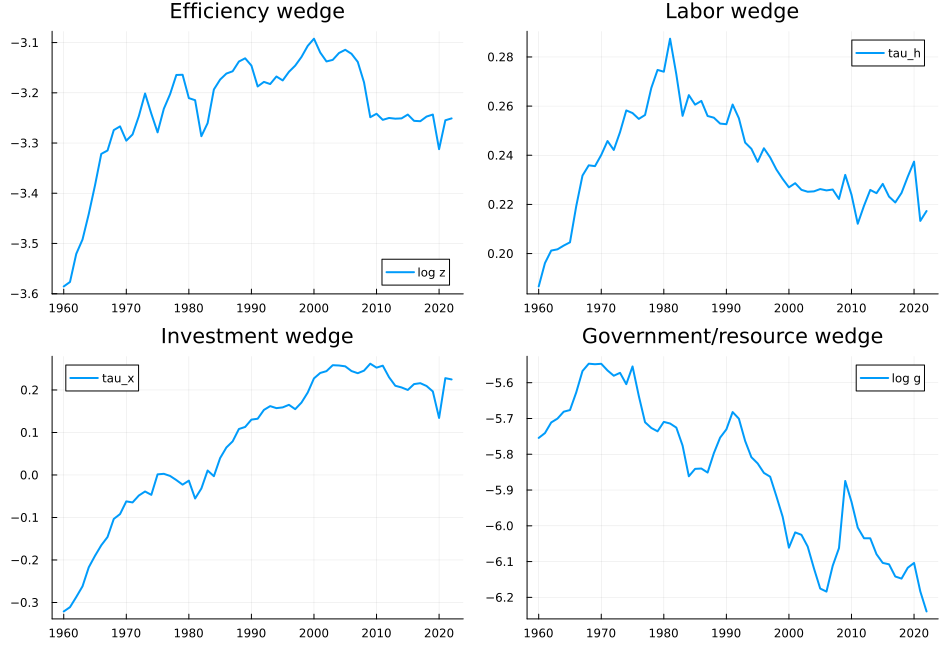

Saved wedge plot to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\figures\estimated_wedges.png


In [21]:
ENV["GKSwstype"] = "100"
using Plots
gr()

years = collect(bca_data.year)
fig_dir = joinpath(pwd(), "figures")
mkpath(fig_dir)

p1 = plot(years, wedges.log_z, title = "Efficiency wedge", label = "log z", linewidth = 2)
p2 = plot(years, wedges.tau_h, title = "Labor wedge", label = "tau_h", linewidth = 2)
p3 = plot(years, wedges.tau_x, title = "Investment wedge", label = "tau_x", linewidth = 2)
p4 = plot(years, wedges.log_g, title = "Government/resource wedge", label = "log g", linewidth = 2)

p_wedges = plot(p1, p2, p3, p4, layout = (2, 2), size = (950, 650))
wedge_plot_file = joinpath(fig_dir, "estimated_wedges.png")
savefig(p_wedges, wedge_plot_file)
println("Saved wedge plot to: ", wedge_plot_file)
display(p_wedges)

## Julia Implementation Step 10: Feed Wedges Back into the Model One at a Time

The `depression/setup.m` and `benchplots.m` files do the one-wedge accounting by changing the realized wedge states, not by changing the structural parameters. Inactive wedges are held fixed at their first-sample values. A no-shock case, with all wedges fixed at their first-sample values, is used as the baseline. For each one-wedge case, we plot the contribution relative to this no-shock baseline, normalized so the first sample year equals 100.

In [22]:
# -------------------------------------------------------
# One-wedge accounting following the setup.m / benchplots.m logic
# -------------------------------------------------------
function counterfactual_wedge_paths(active_columns, actual_paths, first_state)
    T = size(actual_paths, 1)
    paths = ones(T, 1) * reshape(first_state, 1, 4)
    for j in active_columns
        paths[:, j] .= actual_paths[:, j]
    end
    return paths
end

function simulate_bca_observables(S_paths, ss; logk0)
    T = size(S_paths, 1)
    Xsim = zeros(T, 6)
    Ysim = zeros(T, 4)

    Xsim[1, 1] = logk0
    for t in 1:T
        Xsim[t, 2:5] .= S_paths[t, :]
        Xsim[t, 6] = 1.0
        Ysim[t, :] .= ss.C * Xsim[t, :]
        if t < T
            Xsim[t + 1, 1] = dot(ss.gamma, Xsim[t, :])
        end
    end

    return Ysim, Xsim
end

function benchplots_level_contribution(Y_case, Y_no_shock, y_data0)
    # CKM benchplots.m uses: case - no_shock - case(1) + no_shock(1) + data(1).
    y_case = exp.(Y_case[:, 1])
    y_no_shock = exp.(Y_no_shock[:, 1])
    return (y_case .- y_no_shock .- y_case[1] .+ y_no_shock[1]) .+ y_data0
end

normalize_level(level_series) = 100.0 .* level_series ./ level_series[1]
log_deviation_from_level(level_series) = log.(level_series) .- log(level_series[1])

# This simulation is log-linear, so use the linearly consistent z and labor wedge inputs.
S_actual = hcat(wedges.log_z_linear, wedges.tau_h_linear, wedges.tau_x, wedges.log_g)
S_first = vec(S_actual[1, :])
logk0 = ckm_final_inputs.lkt[1]

# Case 1: all measured wedges vary.
S_all = S_actual
Y_all, X_all = simulate_bca_observables(S_all, ss_hat; logk0 = logk0)

# Case 9: no shocks, all wedges fixed at first-sample values.
S_no = counterfactual_wedge_paths(Int[], S_actual, S_first)
Y_no, X_no = simulate_bca_observables(S_no, ss_hat; logk0 = logk0)

# Cases 2, 3, 4, 7 in setup.m: only one wedge varies.
Y_z, X_z = simulate_bca_observables(counterfactual_wedge_paths([1], S_actual, S_first), ss_hat; logk0 = logk0)
Y_h, X_h = simulate_bca_observables(counterfactual_wedge_paths([2], S_actual, S_first), ss_hat; logk0 = logk0)
Y_x, X_x = simulate_bca_observables(counterfactual_wedge_paths([3], S_actual, S_first), ss_hat; logk0 = logk0)
Y_g, X_g = simulate_bca_observables(counterfactual_wedge_paths([4], S_actual, S_first), ss_hat; logk0 = logk0)

y_data_level = exp.(Yobs[:, 1])
y_data0 = y_data_level[1]
y_all_level = exp.(Y_all[:, 1])
y_no_level = exp.(Y_no[:, 1])

# One-wedge contributions relative to no-shock baseline, as in benchplots.m.
y_z_contrib = benchplots_level_contribution(Y_z, Y_no, y_data0)
y_h_contrib = benchplots_level_contribution(Y_h, Y_no, y_data0)
y_x_contrib = benchplots_level_contribution(Y_x, Y_no, y_data0)
y_g_contrib = benchplots_level_contribution(Y_g, Y_no, y_data0)

# Statistics are computed on log deviations of the displayed normalized series.
data_ld = log_deviation_from_level(y_data_level)
all_ld = log_deviation_from_level(y_all_level)
no_ld = log_deviation_from_level(y_no_level)
z_ld = log_deviation_from_level(y_z_contrib)
h_ld = log_deviation_from_level(y_h_contrib)
x_ld = log_deviation_from_level(y_x_contrib)
g_ld = log_deviation_from_level(y_g_contrib)

counterfactual_output = tools.DataFrame(
    year = years,
    data_index = normalize_level(y_data_level),
    all_wedges_index = normalize_level(y_all_level),
    no_shock_index = normalize_level(y_no_level),
    efficiency_only_index = normalize_level(y_z_contrib),
    labor_only_index = normalize_level(y_h_contrib),
    investment_only_index = normalize_level(y_x_contrib),
    government_only_index = normalize_level(y_g_contrib),
    data_log_deviation = data_ld,
    all_wedges_log_deviation = all_ld,
    no_shock_log_deviation = no_ld,
    efficiency_only_log_deviation = z_ld,
    labor_only_log_deviation = h_ld,
    investment_only_log_deviation = x_ld,
    government_only_log_deviation = g_ld
)

p_output = plot(years, counterfactual_output.data_index, label = "data", linewidth = 3, color = :black)
plot!(p_output, years, counterfactual_output.all_wedges_index, label = "all wedges", linewidth = 2, linestyle = :dash)
plot!(p_output, years, counterfactual_output.efficiency_only_index, label = "efficiency only", linewidth = 2)
plot!(p_output, years, counterfactual_output.labor_only_index, label = "labor only", linewidth = 2)
plot!(p_output, years, counterfactual_output.investment_only_index, label = "investment only", linewidth = 2)
plot!(p_output, years, counterfactual_output.government_only_index, label = "government only", linewidth = 2)
plot!(p_output, title = "BCA output accounting", ylabel = "output index, 1960 = 100", xlabel = "year", size = (950, 520))

output_plot_file = joinpath(fig_dir, "one_wedge_output_accounting.png")
savefig(p_output, output_plot_file)
println("Saved output accounting plot to: ", output_plot_file)
display(p_output)

cf_summary = tools.DataFrame(
    experiment = ["all wedges", "no shock", "efficiency only", "labor only", "investment only", "government only"],
    correlation_with_data = [
        tools.cor(data_ld, all_ld),
        tools.cor(data_ld, no_ld),
        tools.cor(data_ld, z_ld),
        tools.cor(data_ld, h_ld),
        tools.cor(data_ld, x_ld),
        tools.cor(data_ld, g_ld)
    ],
    std_relative_to_data = [
        tools.std(all_ld) / tools.std(data_ld),
        tools.std(no_ld) / tools.std(data_ld),
        tools.std(z_ld) / tools.std(data_ld),
        tools.std(h_ld) / tools.std(data_ld),
        tools.std(x_ld) / tools.std(data_ld),
        tools.std(g_ld) / tools.std(data_ld)
    ]
)

cf_output_file = joinpath(data_dir, "hw7_bca_counterfactual_output.csv")
open(cf_output_file, "w") do io
    println(io, "year,data_index,all_wedges_index,no_shock_index,efficiency_only_index,labor_only_index,investment_only_index,government_only_index,data_log_deviation,all_wedges_log_deviation,no_shock_log_deviation,efficiency_only_log_deviation,labor_only_log_deviation,investment_only_log_deviation,government_only_log_deviation")
    for row in tools.eachrow(counterfactual_output)
        println(io, "$(row.year),$(row.data_index),$(row.all_wedges_index),$(row.no_shock_index),$(row.efficiency_only_index),$(row.labor_only_index),$(row.investment_only_index),$(row.government_only_index),$(row.data_log_deviation),$(row.all_wedges_log_deviation),$(row.no_shock_log_deviation),$(row.efficiency_only_log_deviation),$(row.labor_only_log_deviation),$(row.investment_only_log_deviation),$(row.government_only_log_deviation)")
    end
end

cf_summary_file = joinpath(data_dir, "hw7_bca_counterfactual_summary.csv")
open(cf_summary_file, "w") do io
    println(io, "experiment,correlation_with_data,std_relative_to_data")
    for row in tools.eachrow(cf_summary)
        println(io, "$(row.experiment),$(row.correlation_with_data),$(row.std_relative_to_data)")
    end
end

println("Saved counterfactual output to: ", cf_output_file)
println("Saved counterfactual summary to: ", cf_summary_file)
cf_summary



ArgumentError: ArgumentError: column name :log_z_linear not found in the data frame

In [ ]:
# -------------------------------------------------------
# Subwindow analysis in CKM's Figure 5-8 style.
# HW7 sample starts in 1948, so the 1929-1939 Depression window is not
# available. We plot a 1960-1990 window (analogue of CKM Figures 5-8).
# -------------------------------------------------------

function subwindow_idx(yrs, t_start, t_end)
    return findall(y -> t_start <= y <= t_end, yrs)
end

t0_82, t1_82 = 1979.0, 1985.75
idx82 = subwindow_idx(years, t0_82, t1_82)
yrs82 = years[idx82]

# --- Figure 5 style: data output and three measured wedges, 1979 = 100 ---
Zt_lvl = exp.(wedges.log_z)
y_base = y_tilde[idx82][1]
z_base = Zt_lvl[idx82][1]
h_base_wedge = 1.0 - wedges.tau_h[idx82][1]
x_base_wedge = 1.0 + wedges.tau_x[idx82][1]

output_norm82 = 100.0 .* y_tilde[idx82] ./ y_base
eff_norm82    = 100.0 .* (Zt_lvl[idx82] ./ z_base) .^ (1.0 - hw7_params.theta)
lab_norm82    = 100.0 .* (1.0 .- wedges.tau_h[idx82]) ./ h_base_wedge
inv_norm82    = 100.0 .* x_base_wedge ./ (1.0 .+ wedges.tau_x[idx82])

p_fig5 = plot(yrs82, output_norm82, label = "Output", linewidth = 2, color = :black,
              title = "Output and Measured Wedges, 1979-1985 (1979Q1 = 100)",
              xlabel = "year", size = (900, 500))
plot!(p_fig5, yrs82, eff_norm82, label = "Efficiency wedge", linewidth = 2, color = :blue)
plot!(p_fig5, yrs82, lab_norm82, label = "Labor wedge", linewidth = 2, color = :green)
plot!(p_fig5, yrs82, inv_norm82, label = "Investment wedge", linewidth = 2, color = :red)

fig5_file = joinpath(fig_dir, "wedges_levels_1979_1985.png")
savefig(p_fig5, fig5_file)
println("Saved Figure-5-style plot to: ", fig5_file)
display(p_fig5)

# --- Figure 6-8 style: one-wedge output accounting, 1979 = 100 ---
to100(v) = 100.0 .* v ./ v[1]

data_idx82 = to100(y_data_level[idx82])
all_idx82  = to100(y_all_level[idx82])
z_idx82    = to100(y_z_contrib[idx82])
h_idx82    = to100(y_h_contrib[idx82])
x_idx82    = to100(y_x_contrib[idx82])
g_idx82    = to100(y_g_contrib[idx82])

p_acc82 = plot(yrs82, data_idx82, label = "Data", linewidth = 3, color = :black,
               title = "One-wedge Output Accounting, 1979-1985 (1979Q1 = 100)",
               xlabel = "year", size = (900, 500))
plot!(p_acc82, yrs82, all_idx82, label = "All wedges", linewidth = 2, linestyle = :dash)
plot!(p_acc82, yrs82, z_idx82, label = "Efficiency only", linewidth = 2)
plot!(p_acc82, yrs82, h_idx82, label = "Labor only", linewidth = 2)
plot!(p_acc82, yrs82, x_idx82, label = "Investment only", linewidth = 2)
plot!(p_acc82, yrs82, g_idx82, label = "Government only", linewidth = 2)

acc82_file = joinpath(fig_dir, "accounting_1979_1985.png")
savefig(p_acc82, acc82_file)
println("Saved 1979-1985 accounting plot to: ", acc82_file)
display(p_acc82)

subwindow_82 = tools.DataFrame(
    year = yrs82,
    data = data_idx82,
    all_wedges = all_idx82,
    efficiency_only = z_idx82,
    labor_only = h_idx82,
    investment_only = x_idx82,
    government_only = g_idx82
)
subwindow_82